## Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
import re
from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


In [3]:
sentiment_counts = pd.Series(y_train).value_counts()

print(sentiment_counts)

1    12500
0    12500
Name: count, dtype: int64


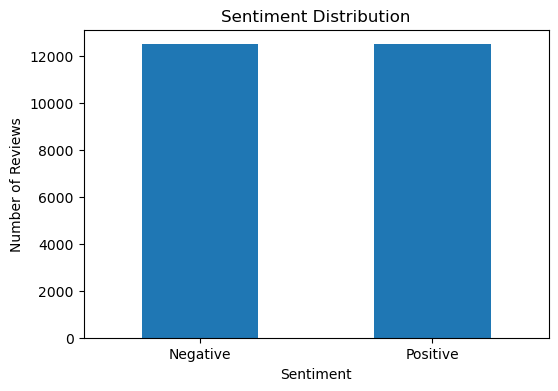

In [4]:
sentiment_counts.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
    rotation=0
)

plt.show()

In [5]:
# Analyze Review Length

review_lengths = [len(review) for review in X_train]

print("Minimum:", min(review_lengths))
print("Maximum:", max(review_lengths))
print("Average:", sum(review_lengths) / len(review_lengths))

Minimum: 11
Maximum: 2494
Average: 238.71364


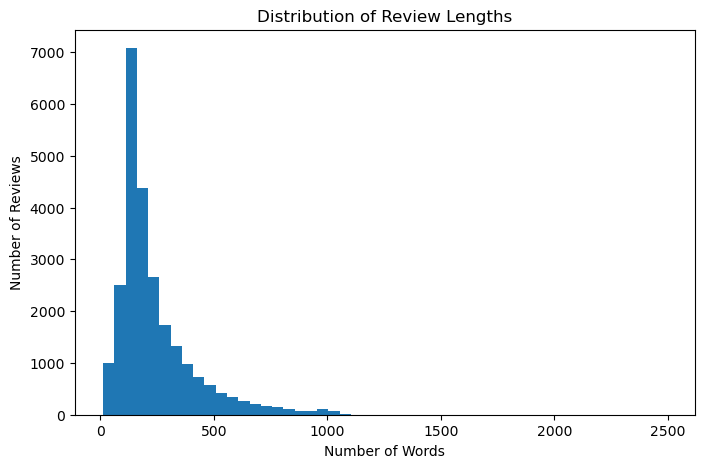

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    review_lengths,
    bins=50
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

In [7]:
X_train = pad_sequences(
    X_train,
    maxlen=200,
    padding="post",
    truncating="post"
)

In [8]:
# Analyze Review Length by Sentiment

positive_lengths = [
    len(X_train[i])
    for i in range(len(X_train))
    if y_train[i] == 1
]

negative_lengths = [
    len(X_train[i])
    for i in range(len(X_train))
    if y_train[i] == 0
]

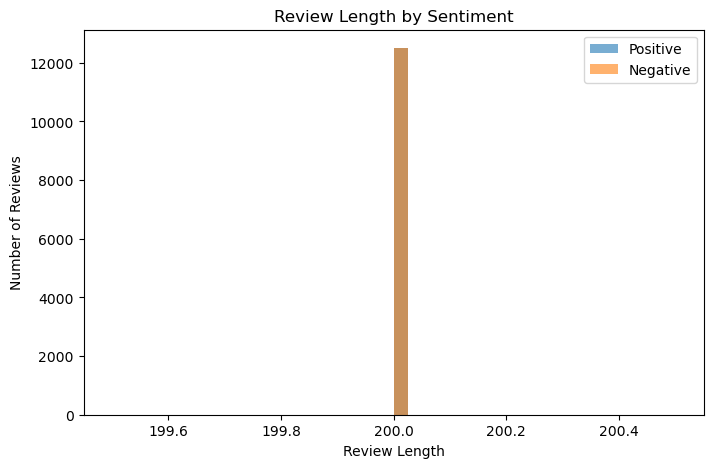

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    positive_lengths,
    bins=40,
    alpha=0.6,
    label="Positive"
)

plt.hist(
    negative_lengths,
    bins=40,
    alpha=0.6,
    label="Negative"
)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Review Length by Sentiment")

plt.legend()
plt.show()

In [10]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

In [11]:
def decode_review(encoded_review):
    return " ".join(
        reverse_word_index.get(i, "<UNK>")
        for i in encoded_review
    )

In [12]:
print(decode_review(X_train[0]))

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

In [15]:
# Get Word Frequency

all_text = " ".join(
    decode_review(review)
    for review in X_train
)

words = re.findall(
    r'\b[a-zA-Z]+\b',
    all_text.lower()
)

word_counts = Counter(words)

print(word_counts.most_common(20))

[('pad', 973100), ('the', 225308), ('unk', 219294), ('a', 111969), ('and', 109695), ('of', 97866), ('to', 89339), ('is', 73229), ('it', 67825), ('i', 67466), ('br', 64733), ('in', 62132), ('this', 56257), ('that', 48208), ('was', 35979), ('movie', 34090), ('as', 30147), ('with', 29169), ('for', 28951), ('but', 28611)]


In [16]:
# Remove Stopwords

import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word not in stop_words
]

word_counts = Counter(filtered_words)

print(word_counts.most_common(20))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('pad', 973100), ('unk', 219294), ('br', 64733), ('movie', 34090), ('film', 27424), ('start', 26267), ('one', 18453), ('like', 13912), ('good', 10736), ('story', 8833), ('time', 8830), ('even', 8375), ('really', 8284), ('would', 8169), ('see', 7838), ('well', 7247), ('bad', 6936), ('first', 6792), ('great', 6606), ('people', 6578)]


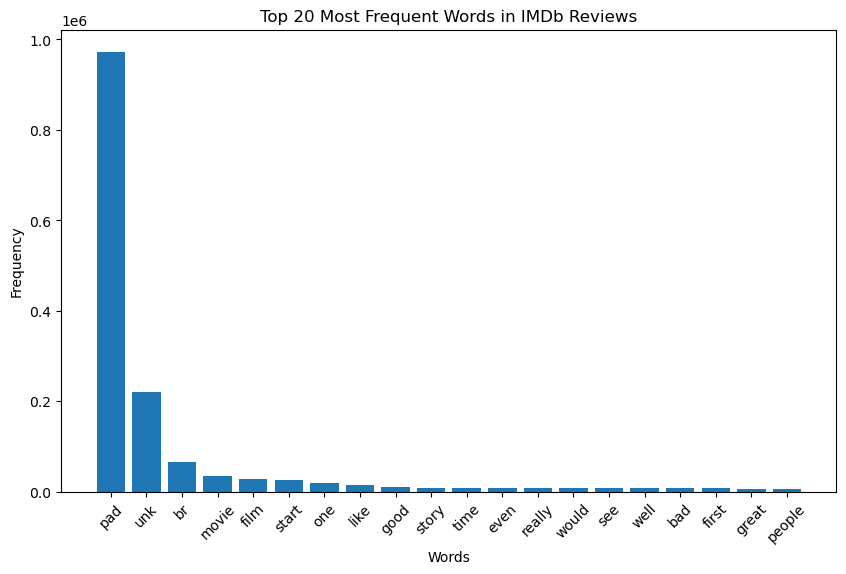

In [17]:
import matplotlib.pyplot as plt

top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(10, 6))

plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in IMDb Reviews")

plt.xticks(rotation=45)

plt.show()

In [18]:
# Creating Seperate posite and negative word list

from collections import Counter

positive_words = []
negative_words = []

for review, label in zip(X_train, y_train):

    words = [
        reverse_word_index.get(i, "<UNK>")
        for i in review
    ]

    if label == 1:
        positive_words.extend(words)
    else:
        negative_words.extend(words)

In [19]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

positive_words = [
    word for word in positive_words
    if word not in stop_words
    and word not in ["<PAD>", "<START>", "<UNK>"]
]

negative_words = [
    word for word in negative_words
    if word not in stop_words
    and word not in ["<PAD>", "<START>", "<UNK>"]
]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
positive_word_counts = Counter(positive_words)
negative_word_counts = Counter(negative_words)

In [21]:
print("Top Positive Words:")

for word, count in positive_word_counts.most_common(20):
    print(word, ":", count)

Top Positive Words:
br : 30488
movie : 14674
film : 13880
one : 9176
like : 6127
good : 5391
story : 4930
great : 4673
time : 4448
well : 4277
see : 4098
really : 3845
first : 3522
would : 3425
also : 3419
people : 3156
even : 3127
love : 3068
best : 3059
much : 2993


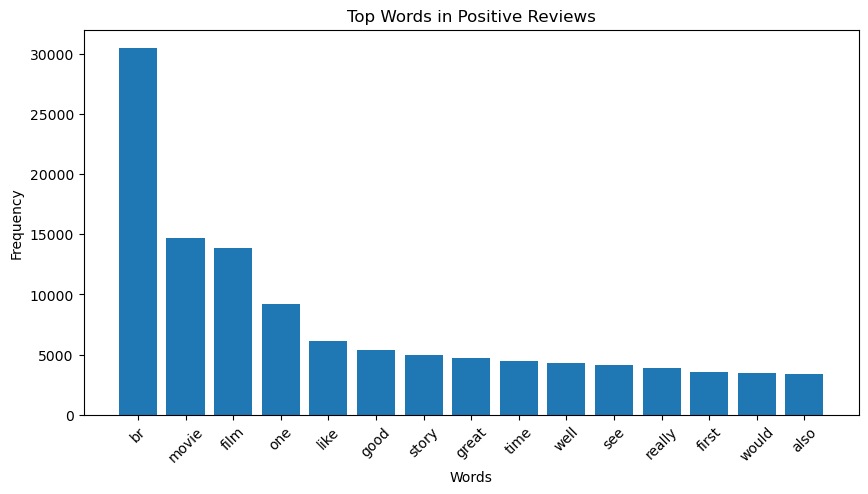

In [22]:

top_positive = positive_word_counts.most_common(15)

words = [x[0] for x in top_positive]
counts = [x[1] for x in top_positive]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top Words in Positive Reviews")

plt.xticks(rotation=45)

plt.show()

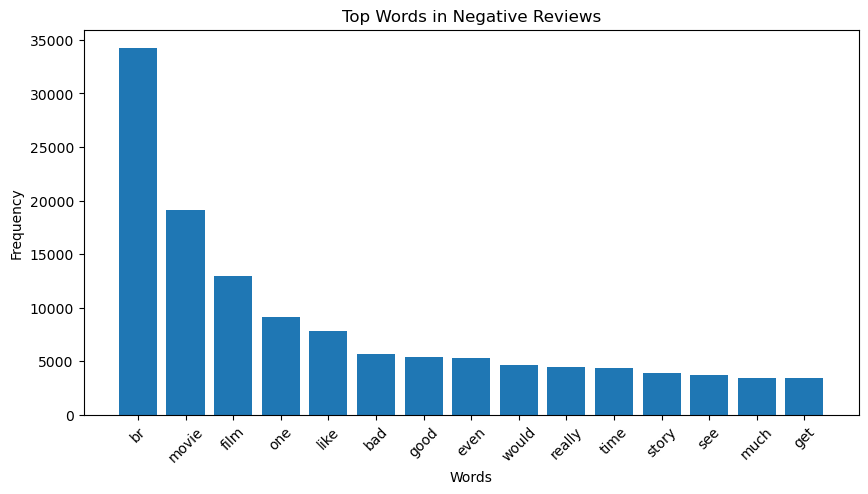

In [23]:
top_negative = negative_word_counts.most_common(15)

words = [x[0] for x in top_negative]
counts = [x[1] for x in top_negative]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top Words in Negative Reviews")

plt.xticks(rotation=45)

plt.show()

In [24]:
# Checking Current Data

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("First review:")
print(X_train[0])

print("First label:")
print(y_train[0])

Training data shape: (25000, 200)
Testing data shape: (25000,)
First review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476


In [25]:
# Checking Labels

print(np.unique(y_train))
print(np.unique(y_test))

[0 1]
[0 1]


In [26]:
# Padding and Truncation

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [27]:
print("Before padding:")
print(X_train[0])

print("\nAfter padding:")
print(X_train_padded[0])

Before padding:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5  144   30 5535   18   51   36   28  224   92 

In [28]:
print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [29]:
zero_count = np.sum(X_train_padded[0] == 0)

print("Number of padding tokens:", zero_count)

Number of padding tokens: 0


In [32]:
# Building the RNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

vocab_size = 10000
embedding_dim = 128
rnn_units = 64

model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    SimpleRNN(rnn_units),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
## Compile the Model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4990 - loss: 0.7012 - val_accuracy: 0.5068 - val_loss: 0.6927
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6105 - loss: 0.6459 - val_accuracy: 0.5014 - val_loss: 0.7232
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.6933 - loss: 0.5130 - val_accuracy: 0.5134 - val_loss: 0.7906
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7178 - loss: 0.4717 - val_accuracy: 0.5048 - val_loss: 0.8840
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.7607 - loss: 0.3807 - val_accuracy: 0.5042 - val_loss: 0.9265


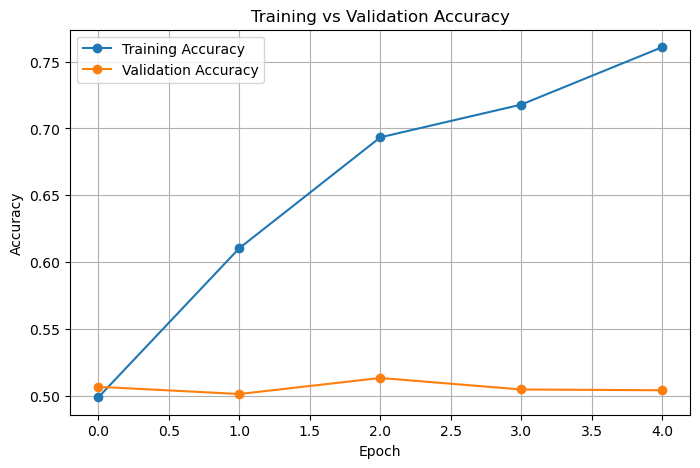

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

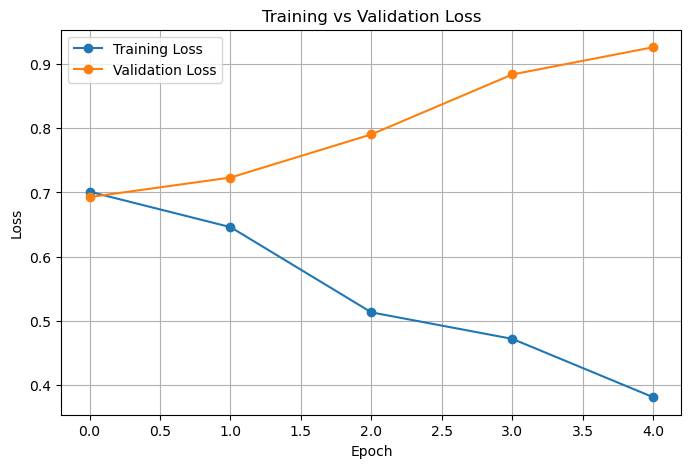

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("X_train_padded:", X_train_padded.shape)
print("X_test_padded:", X_test_padded.shape)

X_train: (25000, 200)
X_test: (25000,)
X_train_padded: (25000, 200)
X_test_padded: (25000, 200)


In [38]:
vocab_size = 10000
embedding_dim = 128
rnn_units = 64
max_length = 200

model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),

    SimpleRNN(rnn_units),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.5875 - loss: 0.6622 - val_accuracy: 0.7220 - val_loss: 0.5513
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.7620 - loss: 0.4976 - val_accuracy: 0.7420 - val_loss: 0.5260
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8891 - loss: 0.2750 - val_accuracy: 0.6598 - val_loss: 0.6745
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.9464 - loss: 0.1459 - val_accuracy: 0.7946 - val_loss: 0.5760
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9764 - loss: 0.0748 - val_accuracy: 0.7552 - val_loss: 0.7951


In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [42]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9922 - loss: 0.0277 - val_accuracy: 0.7244 - val_loss: 0.9626
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9946 - loss: 0.0203 - val_accuracy: 0.7644 - val_loss: 0.9668
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.9984 - loss: 0.0077 - val_accuracy: 0.7724 - val_loss: 0.9989


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

# Clear previous model/session
tf.keras.backend.clear_session()

vocab_size = 10000
embedding_dim = 128
rnn_units = 64
max_length = 200

model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ),

    SimpleRNN(rnn_units),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [46]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.5627 - loss: 0.6757 - val_accuracy: 0.6966 - val_loss: 0.5912
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.7713 - loss: 0.4969 - val_accuracy: 0.6278 - val_loss: 0.6822
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8746 - loss: 0.3028 - val_accuracy: 0.7898 - val_loss: 0.5441
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9391 - loss: 0.1616 - val_accuracy: 0.6360 - val_loss: 0.8318
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9569 - loss: 0.1150 - val_accuracy: 0.6948 - val_loss: 0.9233


In [47]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7627 - loss: 0.6091
Test Loss: 0.6091094017028809
Test Accuracy: 0.762719988822937


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Generate predictions
y_probability = model.predict(
    X_test_padded,
    verbose=1
)

# Convert probabilities to 0/1
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
Predictions generated successfully.


In [49]:
# Calculate classification metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.76272
Precision: 0.820015591502631
Recall   : 0.6732
F1 Score : 0.7393902117564362


In [50]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.72      0.85      0.78     12500
    Positive       0.82      0.67      0.74     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000



In [51]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10653  1847]
 [ 4085  8415]]


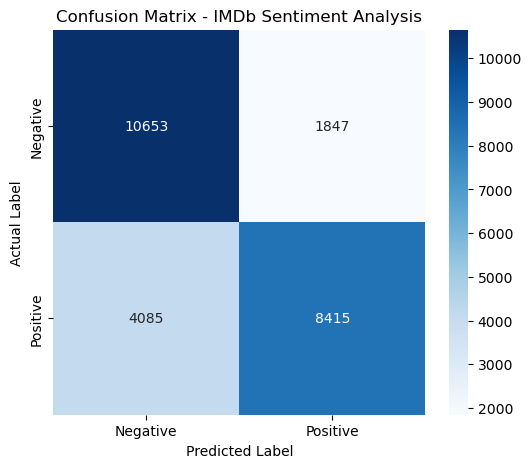

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - IMDb Sentiment Analysis")

plt.show()

In [53]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.76272
Precision: 0.820015591502631
Recall   : 0.6732
F1 Score : 0.7393902117564362


In [54]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.72      0.85      0.78     12500
    Positive       0.82      0.67      0.74     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000



In [57]:
def preprocess_new_review(review):

    words = review.lower().split()

    encoded_review = []

    for word in words:

        index = word_index.get(word)

        if index is not None and index < 10000:
            encoded_review.append(index + 3)
        else:
            encoded_review.append(2)  # Unknown word

    padded_review = pad_sequences(
        [encoded_review],
        maxlen=200,
        padding="post",
        truncating="post"
    )

    return padded_review

In [58]:
def predict_sentiment(review):

    processed_review = preprocess_new_review(review)

    probability = model.predict(
        processed_review,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    print("Review:", review)
    print("Sentiment:", sentiment)
    print("Confidence:", f"{confidence:.2%}")

In [59]:
review = "This movie was amazing and I really enjoyed it."

predict_sentiment(review)

Review: This movie was amazing and I really enjoyed it.
Sentiment: Positive
Confidence: 98.84%


In [60]:
review = "This movie was boring, disappointing and terrible."

predict_sentiment(review)

Review: This movie was boring, disappointing and terrible.
Sentiment: Negative
Confidence: 93.39%


## Conclusion:
In this project, a Recurrent Neural Network (RNN) based sentiment analysis system was developed to classify IMDb movie reviews as positive or negative. The built-in IMDb dataset from TensorFlow/Keras was used, containing 25,000 training reviews and 25,000 testing reviews. Exploratory Data Analysis was performed to understand sentiment distribution and review sequence lengths. The reviews were then padded and truncated to a fixed sequence length of 200 tokens.

The RNN model consisted of an Embedding layer, SimpleRNN layer, Dropout layer, and Sigmoid output layer. Early stopping was used during training to reduce overfitting and restore the best validation weights. The final model achieved a test accuracy of 76.27%, with a precision of 82.02%, recall of 67.32%, and F1-score of 73.99%.

The confusion matrix showed that the model correctly classified 10,653 negative reviews and 8,415 positive reviews. Overall, the project demonstrates that RNNs can learn sequential relationships between words and perform sentiment classification on movie reviews. The model can also be used to predict the sentiment of new movie reviews.

In [61]:
model.save("imdb_rnn_sentiment_model.keras")

In [1]:
from tensorflow.keras.datasets import imdb
import json

word_index = imdb.get_word_index()

with open("word_index.json", "w") as f:
    json.dump(word_index, f)

print("word_index.json saved successfully!")

word_index.json saved successfully!
